# Modeling

## 1. Train/Test Split

Es una técnica fundamental que consiste en dividir un conjunto de datos en dos subgrupos independientes para entrenar un modelo y evaluar objetivamente su rendimiento antes de ponerlo en producción.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from sklearn.model_selection import train_test_split
from src.features import scale_numeric_features, NUMERIC_COLUMNS

X = pd.read_csv("../data/processed/X_features.csv")
y = pd.read_csv("../data/processed/y_target.csv").squeeze()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_test, scaler = scale_numeric_features(X_train, X_test, NUMERIC_COLUMNS)

print("Features de entrenamiento:\n", X_train)
print("Features de test:\n", X_test)

Features de entrenamiento:
            Age  Gender  EducationLevel       BMI  Smoking  AlcoholConsumption  \
780   1.230721       0               1  0.065466        0            1.478214   
1341 -1.430841       1               3  0.070065        1           -0.407432   
820   0.010838       0               0 -0.316941        0           -0.288334   
857   1.563416       0               0 -0.567289        0           -1.418146   
593   0.121737       1               2  1.533521        1           -0.190409   
...        ...     ...             ...       ...      ...                 ...   
1317 -1.652638       0               1  0.517706        0           -1.452272   
711  -1.652638       0               0 -1.014042        0            1.158931   
199   0.010838       1               1 -0.976571        1           -0.720439   
319   0.121737       1               0  0.818305        0           -0.837621   
802  -0.876349       1               2 -1.476374        0           -0.701466   


## 2. Selección y entrenamiento del modelo base

Un modelo base te da una referencia de rendimiento mínimo a superar.El modelo base se elige buscando la opción más simple e interpretable según el tipo de problema.

El proyecto tiene como objetivo predecir la detección temprana del Alzheimer, es decir, si un paciente puede o no tener Alzheimer. Por lo tanto, el modelo base se tiene que elegir para la clasificación binaria con datos tabulares.

Para este caso se probaran todos los modelos para la clasificación binaria.

In [3]:
from src.model import get_models, train_and_evaluate

models = get_models()
trained_models, results_df = train_and_evaluate(models, X_train, y_train, X_test, y_test)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.811628   0.685864  0.861842  0.763848
1        Random Forest  0.951163   0.945578  0.914474  0.929766
2    Gradient Boosting  0.946512   0.927152  0.921053  0.924092
3                  SVM  0.851163   0.801370  0.769737  0.785235
4                  KNN  0.741860   0.684685  0.500000  0.577947


## 3. Interpretación

Revisar cuáles son las variables más relevantes.

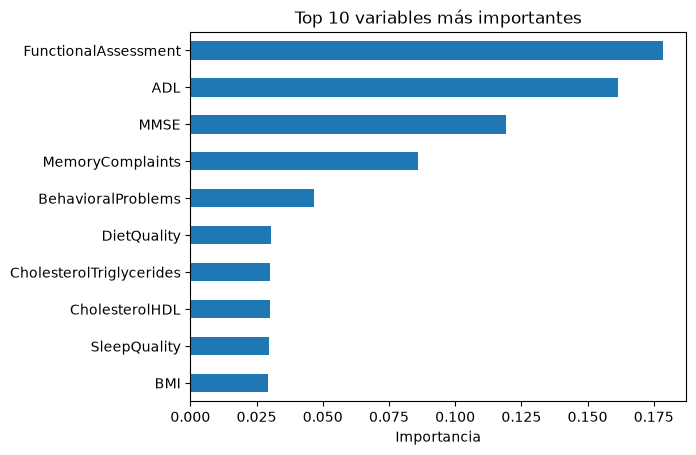

['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'DietQuality', 'CholesterolTriglycerides', 'CholesterolHDL', 'SleepQuality', 'BMI']


In [ ]:
import matplotlib.pyplot as plt
from src.model import get_top_features

rf_model = trained_models["Random Forest"]
top_features = get_top_features(rf_model, X_train, n=10)

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.show()

## 4. Reentrenar modelos con las variables más significativas


In [5]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

trained_models_top10, results_top10_df = train_and_evaluate(
    models, X_train_top, y_train, X_test_top, y_test
)
print(results_top10_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.806977   0.688525  0.828947  0.752239
1        Random Forest  0.953488   0.940000  0.927632  0.933775
2    Gradient Boosting  0.946512   0.927152  0.921053  0.924092
3                  SVM  0.874419   0.831081  0.809211  0.820000
4                  KNN  0.779070   0.752212  0.559211  0.641509


## 5. Simular predicción de un paciente

In [6]:
paciente_nuevo = X_test_top.iloc[[0]]

modelo_final = trained_models_top10["Random Forest"]
pred = modelo_final.predict(paciente_nuevo)
prob = modelo_final.predict_proba(paciente_nuevo)

print("Diagnóstico real:", y_test.iloc[0])
print("Diagnóstico predicho:", pred[0])
print("Probabilidad [sano, Alzheimer]:", prob[0])

Diagnóstico real: 1
Diagnóstico predicho: 1
Probabilidad [sano, Alzheimer]: [0.03 0.97]


## 6. Guardar modelo y features

In [7]:
from src.model import save_artifacts

save_artifacts(
    model=trained_models_top10["Random Forest"],
    scaler=scaler,
    top_features=top_features,
    output_dir="../models"
)